# TARP Calibration Analysis — DiffDock

Tests whether DiffDock's pose distribution is calibrated using the TARP method (Lemos & Coogan et al. 2023).

**ECP above diagonal** = over-dispersed (too many far-from-binding-site poses)  
**ECP below diagonal** = mode-collapsed (misses valid binding modes)

In [4]:
import sys, warnings, os
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from utils.tarp_eval import (
    build_results_index, run_tarp_eval,
    ecp_from_fractions, plot_ecp, atc_score
)

RESULTS_FULL = "../results/testset_eval_full"
MERGED       = "../results/testset_eval_merged"
DATA_DIR     = "../data/PDBBind_processed"

complex_names = np.load(f"{MERGED}/complex_names.npy", allow_pickle=True)
results_index = build_results_index(RESULTS_FULL)
print(f"Complexes: {len(complex_names)}, indexed: {len(results_index)}")

Complexes: 322, indexed: 322


## Phase 1 — Centroid TARP (fast)

Represents each pose as its ligand centroid (3D). Tests whether DiffDock samples the correct region of the protein (binding-site localisation).

In [2]:
# K=100 reference points per complex, ~5–10 seconds on CPU
f_centroid = run_tarp_eval(
    complex_names, results_index, DATA_DIR,
    K=100, mode="centroid", seed=42, verbose=True, n_workers=1
)
np.save(f"{MERGED}/tarp_fractions_centroid.npy", f_centroid)
print(f"Collected {f_centroid.shape[0]} complexes × {f_centroid.shape[1]} references")

  [0/322] processed 6qqw ...
  [20/322] processed 6seo ...


[15:44:31] ERROR: Cannot process coordinates on line 5
[15:44:31] ERROR: moving to the beginning of the next molecule
[15:44:33] UFFTYPER: Warning: hybridization set to SP3 for atom 1


  [40/322] processed 6n9l ...


[15:44:35] ERROR: Cannot process coordinates on line 5
[15:44:35] ERROR: moving to the beginning of the next molecule
[15:44:35] ERROR: Cannot process coordinates on line 5
[15:44:35] ERROR: moving to the beginning of the next molecule
[15:44:36] ERROR: Cannot process coordinates on line 5
[15:44:36] ERROR: moving to the beginning of the next molecule


  [60/322] processed 6ovz ...


...

  [280/322] processed 6k1s ...


[15:45:30] UFFTYPER: Unrecognized hybridization for atom: 24
[15:45:30] UFFTYPER: Unrecognized atom type: Fe (24)
[15:45:33] ERROR: Cannot process coordinates on line 5
[15:45:33] ERROR: moving to the beginning of the next molecule
[15:45:33] ERROR: Cannot process coordinates on line 5
[15:45:33] ERROR: moving to the beginning of the next molecule
[15:45:34] UFFTYPER: Warning: hybridization set to SP3 for atom 0
[15:45:34] UFFTYPER: Warning: hybridization set to SP3 for atom 5
[15:45:34] UFFTYPER: Warning: hybridization set to SP3 for atom 9
[15:45:34] UFFTYPER: Warning: hybridization set to SP3 for atom 20
[15:45:34] UFFTYPER: Warning: hybridization set to SP3 for atom 23
[15:45:34] UFFTYPER: Warning: hybridization set to SP3 for atom 27


  [300/322] processed 6n93 ...


[15:45:37] ERROR: Cannot process coordinates on line 5
[15:45:37] ERROR: moving to the beginning of the next molecule
[15:45:37] ERROR: Cannot process coordinates on line 5
[15:45:37] ERROR: moving to the beginning of the next molecule
[15:45:37] ERROR: Cannot process coordinates on line 5
[15:45:37] ERROR: moving to the beginning of the next molecule
[15:45:37] ERROR: Cannot convert '0 C' to int on line 5
[15:45:37] ERROR: moving to the beginning of the next molecule
[15:45:38] 

****
Post-condition Violation
Element '5 C' not found
Violation occurred on line 93 in file /project/build/temp.linux-x86_64-cpython-39/rdkit/Code/GraphMol/PeriodicTable.h
Failed Expression: anum > -1
****

[15:45:38] ERROR: Element '5 C' not found
[15:45:38] ERROR: moving to the beginning of the next molecule


  [320/322] processed 6r7d ...
Done. 322 complexes processed, 0 skipped.
Collected 322 complexes × 100 references


ATC score (centroid): 0.0150
  (positive = over-dispersed, negative = mode-collapsed, 0 = perfect)


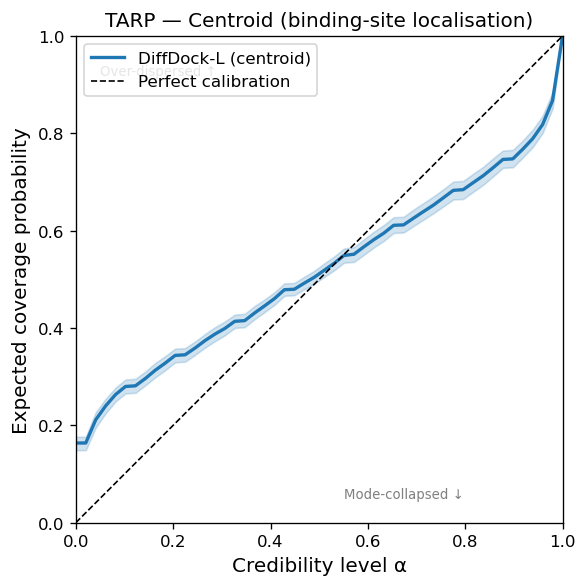

In [3]:
from utils.tarp_eval import bootstrap_ecp
ecp_c, alpha_c = ecp_from_fractions(f_centroid, n_bins=50)
boot_c = bootstrap_ecp(f_centroid, n_bootstrap=500)
print(f"ATC score (centroid): {atc_score(ecp_c, alpha_c):.4f}")
print(f"  (positive = over-dispersed, negative = mode-collapsed, 0 = perfect)")

fig, ax = plt.subplots(figsize=(5, 5))
plot_ecp(ecp_c, alpha_c, ax=ax, label="DiffDock-L (centroid)", color="C0", bootstrap_ecps=boot_c)
ax.set_title("TARP — Centroid (binding-site localisation)")
plt.tight_layout()
plt.savefig(f"{MERGED}/tarp_ecp_centroid.png", dpi=150, bbox_inches='tight')
plt.show()

## Phase 2 — Full RMSD TARP

Uses symmetry-corrected RMSD (spyrmsd) over all heavy atoms. Tests full 3D pose calibration including orientation and torsion angles.

> **Runtime:** ~20–40 min for K=100 on CPU. Run the cell below on a compute node, or reduce K for a quick check.

In [ ]:
# Set K=10 for a fast local test; use K=100 for the full result (run on compute node)
K_RMSD = 10  # increase to 100 for publication-quality results

f_rmsd = run_tarp_eval(
    complex_names, results_index, DATA_DIR,
    K=K_RMSD, mode="rmsd", seed=42, verbose=True, n_workers=1
)
np.save(f"{MERGED}/tarp_fractions_rmsd_K{K_RMSD}.npy", f_rmsd)
print(f"Collected {f_rmsd.shape[0]} complexes × {f_rmsd.shape[1]} references")

In [ ]:
from utils.tarp_eval import bootstrap_ecp
K_RMSD = 1

if os.path.exists(f"{MERGED}/tarp_fractions_rmsd_K{K_RMSD}.npy"):
    f_rmsd = np.load(f"{MERGED}/tarp_fractions_rmsd_K{K_RMSD}.npy")

ecp_r, alpha_r = ecp_from_fractions(f_rmsd, n_bins=50)
boot_r = bootstrap_ecp(f_rmsd, n_bootstrap=500)
print(f"ATC score (RMSD, K={K_RMSD}): {atc_score(ecp_r, alpha_r):.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
plot_ecp(ecp_r, alpha_r, ax=ax, label=f"DiffDock-L (RMSD, K={K_RMSD})", color="C1", bootstrap_ecps=boot_r)
ax.set_title("TARP — Full RMSD (pose calibration)")
plt.tight_layout()
plt.savefig(f"{MERGED}/tarp_ecp_rmsd.png", dpi=150, bbox_inches='tight')
plt.show()

## Combined plot

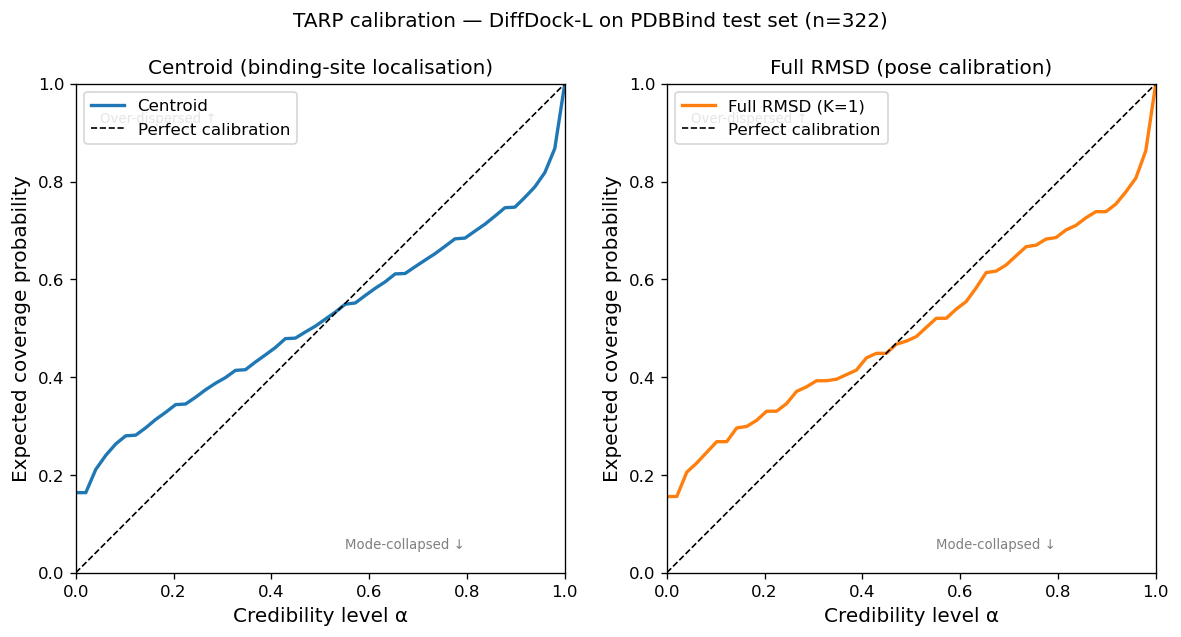

ATC centroid: +0.0150
ATC RMSD:     +0.0024


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_ecp(ecp_c, alpha_c, ax=axes[0], label="Centroid", color="C0")
axes[0].set_title("Centroid (binding-site localisation)")
plot_ecp(ecp_r, alpha_r, ax=axes[1], label=f"Full RMSD (K={K_RMSD})", color="C1")
axes[1].set_title("Full RMSD (pose calibration)")
plt.suptitle("TARP calibration — DiffDock-L on PDBBind test set (n=322)", y=1.02)
plt.tight_layout()
plt.savefig(f"{MERGED}/tarp_ecp_combined.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"ATC centroid: {atc_score(ecp_c, alpha_c):+.4f}")
print(f"ATC RMSD:     {atc_score(ecp_r, alpha_r):+.4f}")

## Per-complex coverage distribution

For each complex, compute the mean coverage fraction (average f over K references). High mean f = over-dispersed for that complex; low mean f = mode-collapsed.

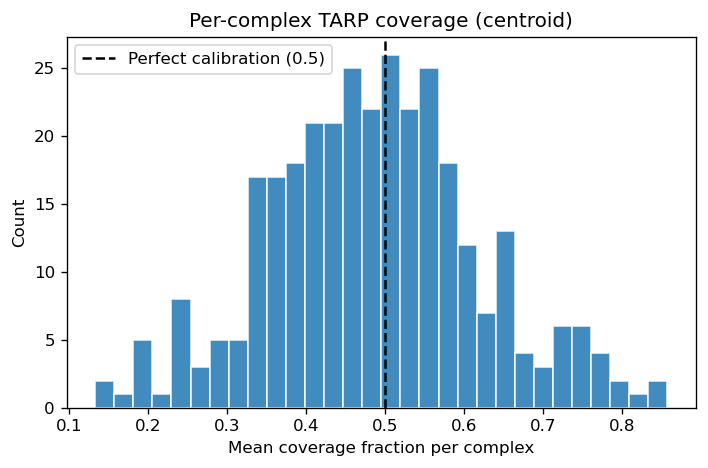

Complexes with mean f > 0.5 (over-dispersed): 46.3%
Complexes with mean f < 0.5 (mode-collapsed): 53.4%


In [7]:
# Reshape fractions back to (n_complexes, K)
# f_centroid is already (n_complexes, K) — no reshape needed
mean_f_per_complex = np.nanmean(f_centroid, axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mean_f_per_complex, bins=30, color="C0", edgecolor="white", alpha=0.85)
ax.axvline(0.5, color="k", linestyle="--", label="Perfect calibration (0.5)")
ax.set_xlabel("Mean coverage fraction per complex")
ax.set_ylabel("Count")
ax.set_title("Per-complex TARP coverage (centroid)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{MERGED}/tarp_per_complex_hist.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Complexes with mean f > 0.5 (over-dispersed): {(mean_f_per_complex > 0.5).mean()*100:.1f}%")
print(f"Complexes with mean f < 0.5 (mode-collapsed): {(mean_f_per_complex < 0.5).mean()*100:.1f}%")

## Top-1 RMSD — success rate curve

For each complex, takes the single top-ranked prediction (by confidence score) and computes its symmetry-corrected RMSD to the crystal structure. Plots the cumulative fraction of complexes below each RMSD threshold — the standard docking benchmark plot. A prediction is conventionally considered a success at < 2 Å.

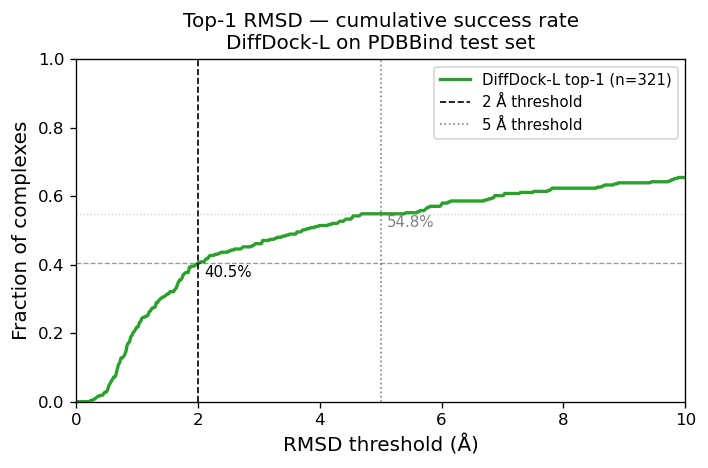

Median RMSD:    3.72 Å
Mean RMSD:      12.85 Å
Fraction < 2 Å: 0.405
Fraction < 5 Å: 0.548


In [9]:
top1_rmsd = np.load(f"{MERGED}/top1_rmsd.npy")
valid = top1_rmsd[np.isfinite(top1_rmsd)]

thresholds = np.linspace(0, 10, 500)
cdf = np.array([(valid < t).mean() for t in thresholds])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thresholds, cdf, color="C2", lw=2, label=f"DiffDock-L top-1 (n={len(valid)})")
ax.axvline(2, color="k", linestyle="--", lw=1, label="2 Å threshold")
ax.axvline(5, color="grey", linestyle=":", lw=1, label="5 Å threshold")
ax.axhline((valid < 2).mean(), color="k", linestyle="--", lw=0.8, alpha=0.4)
ax.axhline((valid < 5).mean(), color="grey", linestyle=":", lw=0.8, alpha=0.4)

ax.text(2.1, (valid < 2).mean() - 0.04, f"{(valid < 2).mean()*100:.1f}%", fontsize=9, color="k")
ax.text(5.1, (valid < 5).mean() - 0.04, f"{(valid < 5).mean()*100:.1f}%", fontsize=9, color="grey")

ax.set_xlabel("RMSD threshold (Å)", fontsize=12)
ax.set_ylabel("Fraction of complexes", fontsize=12)
ax.set_title("Top-1 RMSD — cumulative success rate\nDiffDock-L on PDBBind test set")
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{MERGED}/top1_rmsd_cdf.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Median RMSD:    {np.median(valid):.2f} Å")
print(f"Mean RMSD:      {np.mean(valid):.2f} Å")
print(f"Fraction < 2 Å: {(valid < 2).mean():.3f}")
print(f"Fraction < 5 Å: {(valid < 5).mean():.3f}")

## TARP by Protein Family — RMSD

Uses the pre-computed `tarp_fractions_rmsd_K1.npy` (K=1 reference point, all 40 samples, 321 complexes).
Groups complexes into 7 biologically meaningful families via `pdb_annotations.csv` and plots per-group ECP curves + an ATC bar chart.

> **Note:** The RMSD file has 321 rows vs 322 complex names. The K=1 job ran on a slightly older 321-entry list (same order, same first/last complex). The one tail complex is excluded from this analysis.

Group                     N    ATC (RMSD K=1)  Calibration
--------------------------------------------------------------
Hydrolases               69           +0.0149  calibrated
Transferases             82           -0.0019  calibrated
Sugar Binding            28           +0.0171  calibrated
Signaling                22           -0.0283  mode-collapsed
Transcription/Gene       33           +0.0779  over-dispersed
Oxidoreductases           9           -0.2551  mode-collapsed
Other                    78           -0.0033  calibrated

ALL (baseline)          321           +0.0024


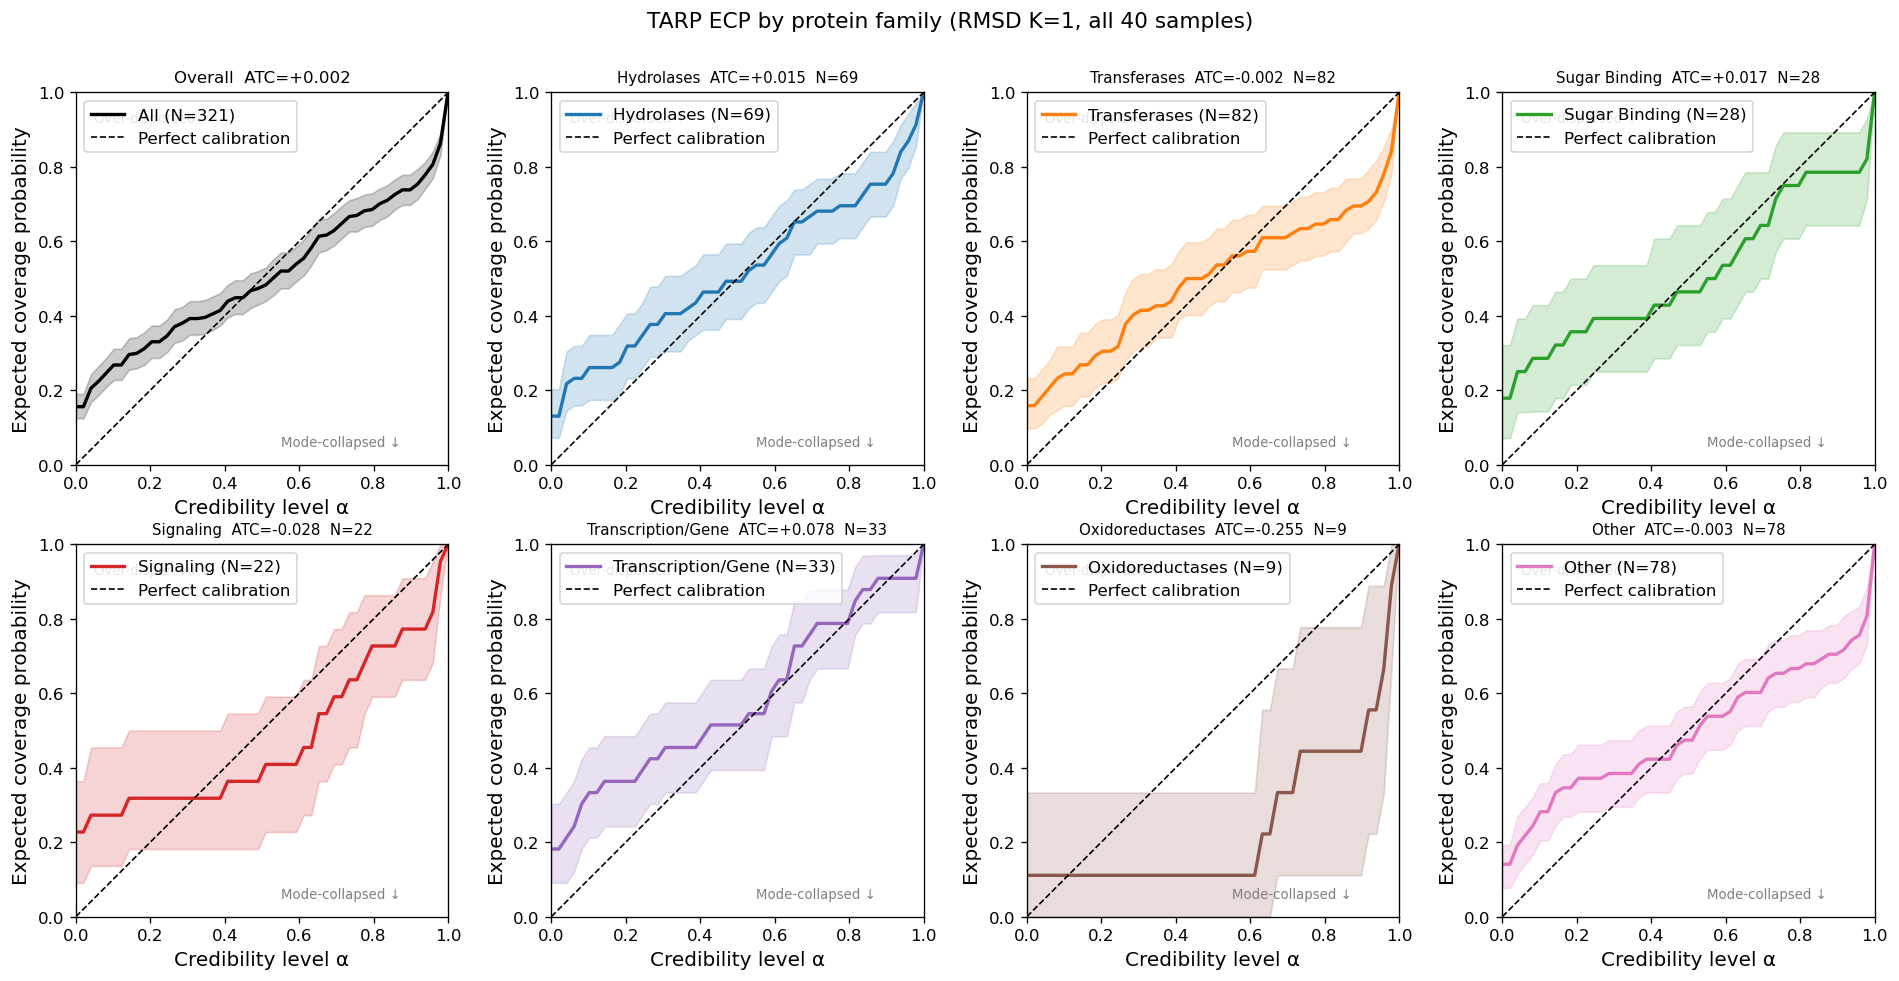

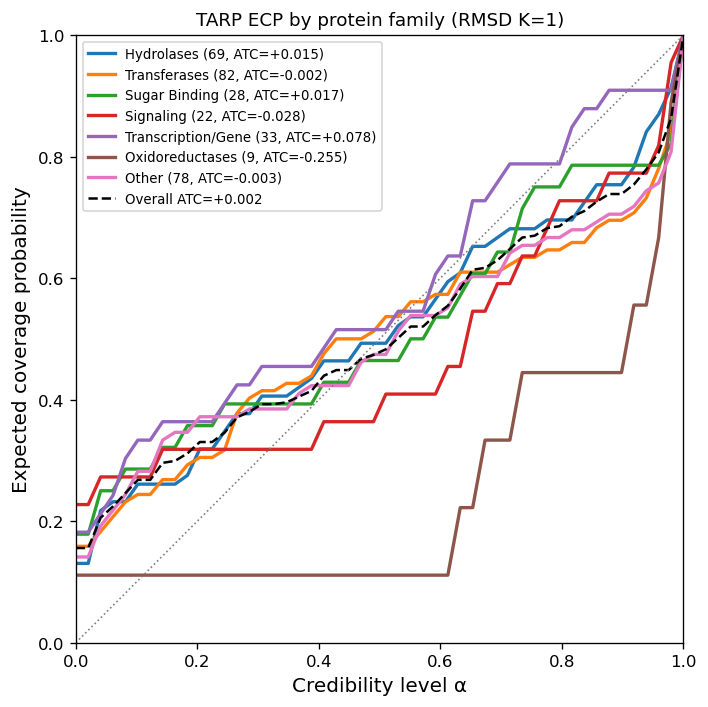

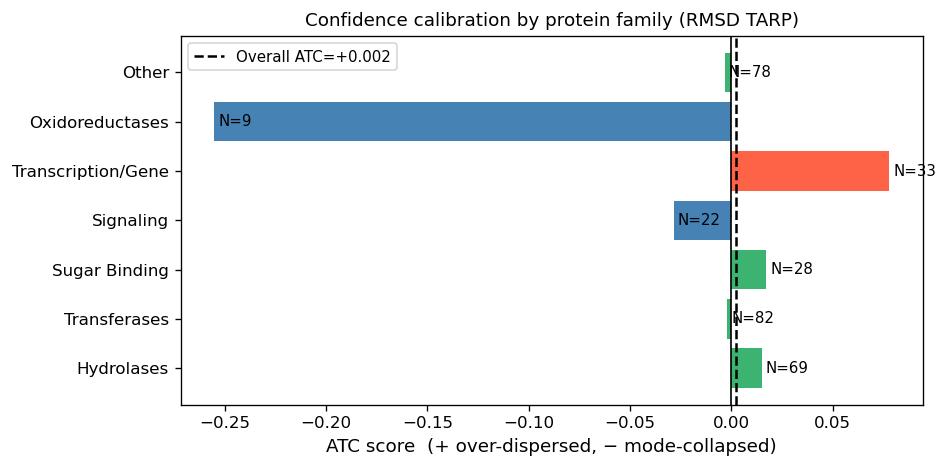

In [2]:
import pandas as pd
from utils.tarp_eval import bootstrap_ecp

# --- Load pre-computed RMSD fractions ---
f_rmsd_k1 = np.load(f"{MERGED}/tarp_fractions_rmsd_K1.npy")   # (321, 1)
names_rmsd = complex_names[:321]                                # same order, one tail name excluded

# --- Protein annotations ---
ann = pd.read_csv("../data/pdb_annotations.csv")
ann_map = dict(zip(ann["pdb_id"], ann["protein_class"].fillna("Unknown")))

# --- Group definitions (first match wins) ---
GROUPS = [
    ("Hydrolases",         lambda c: "hydrolase"    in c.lower()),
    ("Transferases",       lambda c: "transferase"  in c.lower()),
    ("Sugar Binding",      lambda c: "sugar binding" in c.lower()),
    ("Signaling",          lambda c: "signaling"    in c.lower()),
    ("Transcription/Gene", lambda c: any(k in c.lower() for k in
                                         ("transcription", "nuclear protein",
                                          "dna binding", "rna binding", "gene regulation"))),
    ("Oxidoreductases",    lambda c: "oxidoreductase" in c.lower()),
    ("Other",              lambda c: True),
]
COLORS = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]

def assign_group(prot_class):
    for name, fn in GROUPS:
        if fn(prot_class):
            return name
    return "Other"

group_labels = np.array([assign_group(ann_map.get(n, "Unknown")) for n in names_rmsd])

# --- Per-group ECP + ATC ---
rng = np.random.default_rng(42)
group_results = {}
print(f"{'Group':<22} {'N':>4}  {'ATC (RMSD K=1)':>16}  {'Calibration'}")
print("-" * 62)

for grp_name, _ in GROUPS:
    mask = group_labels == grp_name
    n = mask.sum()
    if n == 0:
        continue
    f_grp = f_rmsd_k1[mask]
    ecp, alpha = ecp_from_fractions(f_grp)
    atc = atc_score(ecp, alpha)
    boot = bootstrap_ecp(f_grp, n_bootstrap=500, rng=rng)
    group_results[grp_name] = dict(n=n, f=f_grp, ecp=ecp, alpha=alpha, atc=atc, boot=boot)
    direction = ("over-dispersed" if atc >  0.02 else
                 "mode-collapsed" if atc < -0.02 else "calibrated")
    print(f"{grp_name:<22} {n:>4}  {atc:>+16.4f}  {direction}")

ecp_all, alpha_all = ecp_from_fractions(f_rmsd_k1)
atc_all = atc_score(ecp_all, alpha_all)
boot_all = bootstrap_ecp(f_rmsd_k1, n_bootstrap=500, rng=rng)
print(f"\n{'ALL (baseline)':<22} {len(names_rmsd):>4}  {atc_all:>+16.4f}")

# --- Panel plot ---
ncols, n_groups = 4, len(group_results)
nrows = (n_groups + 1 + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.ravel()

plot_ecp(ecp_all, alpha_all, ax=axes[0], label=f"All (N={len(names_rmsd)})",
         color="black", bootstrap_ecps=boot_all)
axes[0].set_title(f"Overall  ATC={atc_all:+.3f}", fontsize=10)

for i, ((grp_name, _), color) in enumerate(zip(group_results.items(), COLORS)):
    res = group_results[grp_name]
    plot_ecp(res["ecp"], res["alpha"], ax=axes[i + 1],
             label=f"{grp_name} (N={res['n']})", color=color, bootstrap_ecps=res["boot"])
    axes[i + 1].set_title(f"{grp_name}  ATC={res['atc']:+.3f}  N={res['n']}", fontsize=9)

for j in range(i + 2, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("TARP ECP by protein family (RMSD K=1, all 40 samples)", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f"{MERGED}/tarp_ecp_rmsd_by_group_panels.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Overlay plot ---
fig2, ax2 = plt.subplots(figsize=(6, 6))
for (grp_name, _), color in zip(group_results.items(), COLORS):
    res = group_results[grp_name]
    ax2.plot(res["alpha"], res["ecp"], color=color, lw=2,
             label=f"{grp_name} ({res['n']}, ATC={res['atc']:+.3f})")
ax2.plot(alpha_all, ecp_all, "k--", lw=1.5, label=f"Overall ATC={atc_all:+.3f}")
ax2.plot([0, 1], [0, 1], "grey", lw=1, ls=":")
ax2.set_xlabel("Credibility level α", fontsize=12)
ax2.set_ylabel("Expected coverage probability", fontsize=12)
ax2.set_title("TARP ECP by protein family (RMSD K=1)", fontsize=11)
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_aspect("equal")
ax2.legend(fontsize=8, loc="upper left")
fig2.tight_layout()
fig2.savefig(f"{MERGED}/tarp_ecp_rmsd_by_group_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

# --- ATC bar chart ---
fig3, ax3 = plt.subplots(figsize=(8, 4))
grp_names = list(group_results.keys())
atcs = [group_results[g]["atc"] for g in grp_names]
ns   = [group_results[g]["n"]   for g in grp_names]
bars = ax3.barh(grp_names, atcs,
                color=["tomato" if a > 0.02 else "steelblue" if a < -0.02
                       else "mediumseagreen" for a in atcs])
ax3.axvline(0,       color="black", lw=1)
ax3.axvline(atc_all, color="black", lw=1.5, ls="--", label=f"Overall ATC={atc_all:+.3f}")
ax3.set_xlabel("ATC score  (+ over-dispersed, − mode-collapsed)", fontsize=11)
ax3.set_title("Confidence calibration by protein family (RMSD TARP)", fontsize=11)
for bar, n in zip(bars, ns):
    ax3.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
             f"N={n}", va="center", fontsize=9)
ax3.legend(fontsize=9)
fig3.tight_layout()
fig3.savefig(f"{MERGED}/tarp_atc_rmsd_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

## MIRA Score by Protein Family

MIRA (Sharief et al. 2026) tests calibration by drawing random centers in the full all-atom coordinate space and checking whether the crystal pose falls inside the same ball as DiffDock's predicted samples.

**Reference value ≈ 0.683** for S=40 samples (Beta(2,1) null).  
Score **above 0.683** = over-dispersed. Score **below 0.683** = mode-collapsed.

Distance metric: per-atom RMSD (Euclidean in flat coordinate space divided by √n_atoms). Run per-complex (T=1 each, different atom counts), aggregated externally. Group error bars from bootstrapping over per-complex scores. X-axis labels include % of complexes with best-of-40 RMSD < 2 Å.

In [5]:
from utils.mira_eval import compute_mira_scores, bootstrap_mira_groups, mira_null, compute_rmsd_accuracy

MIRA_SCORES_PATH = f"{MERGED}/mira_scores_rmsd.npy"
MIRA_NAMES_PATH  = f"{MERGED}/mira_names_rmsd.npy"
RMSD_ACC_PATH    = f"{MERGED}/rmsd_accuracy.npz"

if os.path.exists(MIRA_SCORES_PATH):
    mira_names  = np.load(MIRA_NAMES_PATH,  allow_pickle=True)
    mira_scores = np.load(MIRA_SCORES_PATH)
    print(f"Loaded cached MIRA scores ({len(mira_scores)} complexes)")
else:
    mira_names, mira_scores = compute_mira_scores(
        complex_names, results_index, DATA_DIR,
        num_runs=100, verbose=True, metric="rmsd",
    )
    np.save(MIRA_NAMES_PATH,  mira_names)
    np.save(MIRA_SCORES_PATH, mira_scores)

if os.path.exists(RMSD_ACC_PATH):
    _acc = np.load(RMSD_ACC_PATH, allow_pickle=True)
    rmsd_acc_names = _acc["names"]
    rmsd_acc_min   = _acc["min_rmsds"]
    rmsd_acc_fracs = _acc["fracs"]
    print(f"Loaded cached RMSD accuracy ({len(rmsd_acc_names)} complexes)")
else:
    rmsd_acc_names, rmsd_acc_min, rmsd_acc_fracs = compute_rmsd_accuracy(
        complex_names, results_index, DATA_DIR,
        thresholds=(2.0, 5.0), verbose=True,
    )
    np.savez(RMSD_ACC_PATH, names=rmsd_acc_names, min_rmsds=rmsd_acc_min, fracs=rmsd_acc_fracs)

REF = mira_null(S=40)
print(f"\nOverall MIRA score: {mira_scores.mean():.4f} ± {mira_scores.std():.4f}")
print(f"Reference (perfect calibration): {REF:.4f}")
overall_pct_2 = (rmsd_acc_min < 2.0).mean() * 100
overall_pct_5 = (rmsd_acc_min < 5.0).mean() * 100
print(f"Overall RMSD accuracy: {overall_pct_2:.1f}% <2Å, {overall_pct_5:.1f}% <5Å  (best-of-N)")

Loaded cached MIRA scores (322 complexes)
Loaded cached RMSD accuracy (322 complexes)

Overall MIRA score: 0.6180 ± 0.0870
Reference (perfect calibration): 0.6833
Overall RMSD accuracy: 55.9% <2Å, 78.3% <5Å  (best-of-N)


Group                     N    MIRA score              90% CI     <2Å%          vs ref
--------------------------------------------------------------------------------------
Hydrolases               69        0.6228  [0.6050, 0.6394]    72.5%  mode-collapsed
Transferases             82        0.6040  [0.5877, 0.6173]    54.9%  mode-collapsed
Sugar Binding            28        0.6039  [0.5737, 0.6306]    53.6%  mode-collapsed
Signaling                22        0.6340  [0.6071, 0.6638]    31.8%  mode-collapsed
Transcription/Gene       33        0.6544  [0.6340, 0.6730]    81.8%  mode-collapsed
Oxidoreductases           9        0.6080  [0.5578, 0.6604]    11.1%  mode-collapsed
Other                    79        0.6147  [0.5983, 0.6325]    44.3%  mode-collapsed

Overall                 322        0.6180  [0.6107, 0.6266]  55.9%
Reference                          0.6833


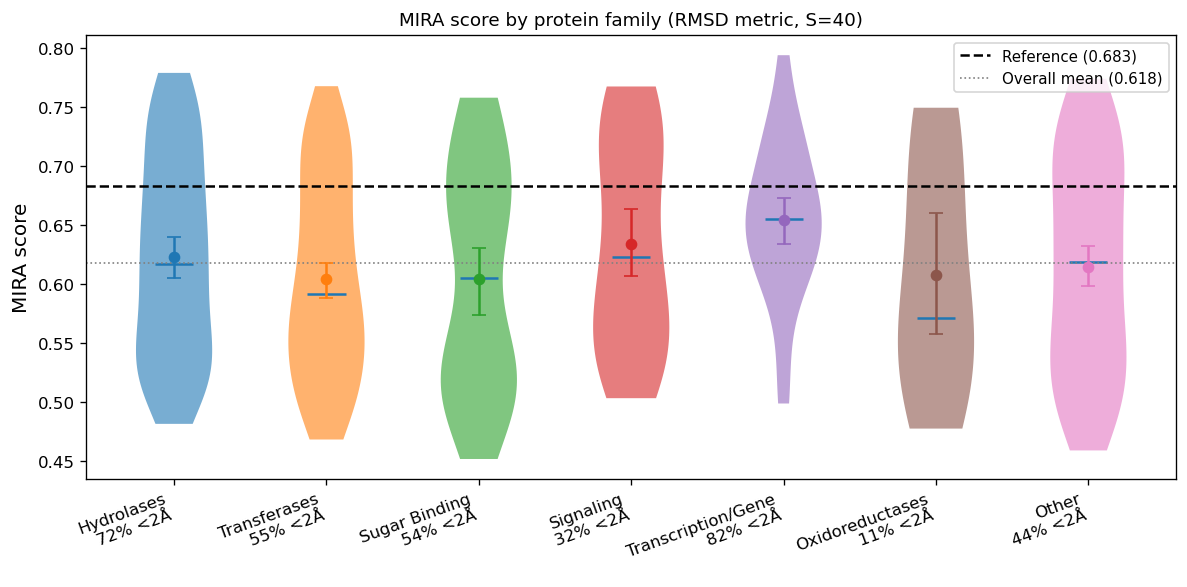

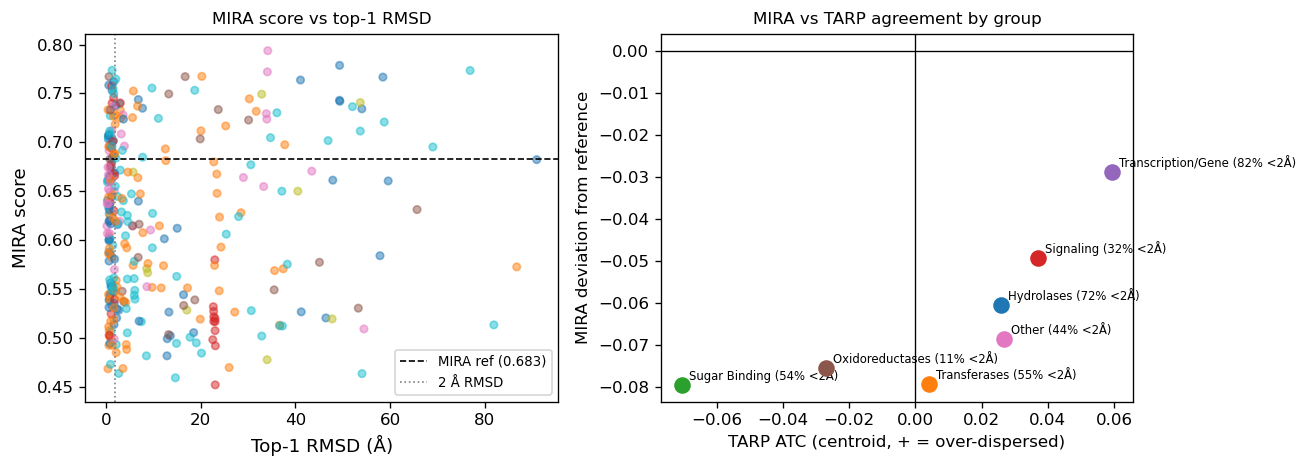

In [6]:
import pandas as pd

# --- Assign protein groups (same definitions as TARP section) ---
ann     = pd.read_csv("../data/pdb_annotations.csv")
ann_map = dict(zip(ann["pdb_id"], ann["protein_class"].fillna("Unknown")))

GROUPS = [
    ("Hydrolases",         lambda c: "hydrolase"     in c.lower()),
    ("Transferases",       lambda c: "transferase"   in c.lower()),
    ("Sugar Binding",      lambda c: "sugar binding" in c.lower()),
    ("Signaling",          lambda c: "signaling"     in c.lower()),
    ("Transcription/Gene", lambda c: any(k in c.lower() for k in
                                         ("transcription", "nuclear protein",
                                          "dna binding", "rna binding", "gene regulation"))),
    ("Oxidoreductases",    lambda c: "oxidoreductase" in c.lower()),
    ("Other",              lambda c: True),
]
GROUP_NAMES = [g[0] for g in GROUPS]
COLORS      = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]

def assign_group(pc):
    for name, fn in GROUPS:
        if fn(pc): return name
    return "Other"

mira_group_labels = np.array([assign_group(ann_map.get(n, "Unknown")) for n in mira_names])

# --- Per-group RMSD accuracy (best-of-N: fraction of complexes with min RMSD < 2 Å) ---
rmsd_group_labels = np.array([assign_group(ann_map.get(n, "Unknown")) for n in rmsd_acc_names])
rmsd_lt2_map = {}
for grp in GROUP_NAMES:
    mask = rmsd_group_labels == grp
    if mask.sum() == 0:
        rmsd_lt2_map[grp] = np.nan
        continue
    rmsd_lt2_map[grp] = (rmsd_acc_min[mask] < 2.0).mean() * 100  # percent

# --- Bootstrap per-group MIRA stats ---
rng         = np.random.default_rng(42)
group_stats = bootstrap_mira_groups(mira_scores, mira_group_labels, GROUP_NAMES,
                                    n_bootstrap=500, rng=rng)

# --- Print table ---
print(f"{'Group':<22} {'N':>4}  {'MIRA score':>12}  {'90% CI':>18}  {'<2Å%':>7}  {'vs ref':>14}")
print("-" * 86)
for grp in GROUP_NAMES:
    if grp not in group_stats: continue
    s = group_stats[grp]
    diff = s['mean'] - REF
    direction = "over-dispersed" if diff > 0.01 else "mode-collapsed" if diff < -0.01 else "calibrated"
    pct = rmsd_lt2_map.get(grp, np.nan)
    pct_str = f"{pct:.1f}%" if np.isfinite(pct) else "N/A"
    print(f"{grp:<22} {s['n']:>4}  {s['mean']:>12.4f}  "
          f"[{s['lo']:.4f}, {s['hi']:.4f}]  {pct_str:>7}  {direction}")
overall_lo = np.percentile(
    [np.random.default_rng(42+b).choice(mira_scores, size=len(mira_scores), replace=True).mean()
     for b in range(500)], [5, 95])
print(f"\n{'Overall':<22} {len(mira_scores):>4}  {mira_scores.mean():>12.4f}  "
      f"[{overall_lo[0]:.4f}, {overall_lo[1]:.4f}]  {overall_pct_2:.1f}%")
print(f"{'Reference':22}       {REF:>12.4f}")

# --- Figure 1: violin plot per group ---
fig, ax = plt.subplots(figsize=(10, 5))
data_by_group  = [mira_scores[mira_group_labels == g] for g in GROUP_NAMES
                  if (mira_group_labels == g).any()]
present_groups = [g for g in GROUP_NAMES if (mira_group_labels == g).any()]
vp = ax.violinplot(data_by_group, positions=np.arange(len(present_groups)),
                   showmedians=True, showextrema=False)
for pc, color in zip(vp["bodies"], COLORS):
    pc.set_facecolor(color); pc.set_alpha(0.6)
for i, (grp, color) in enumerate(zip(present_groups, COLORS)):
    s = group_stats[grp]
    ax.errorbar(i, s["mean"], yerr=[[s["mean"]-s["lo"]], [s["hi"]-s["mean"]]],
                fmt="o", color=color, capsize=4, ms=6, zorder=5)
ax.axhline(REF, color="black", lw=1.5, ls="--", label=f"Reference ({REF:.3f})")
ax.axhline(mira_scores.mean(), color="grey", lw=1, ls=":", label=f"Overall mean ({mira_scores.mean():.3f})")
ax.set_xticks(np.arange(len(present_groups)))
tick_labels = [
    f"{g}\n{rmsd_lt2_map[g]:.0f}% <2Å" if np.isfinite(rmsd_lt2_map.get(g, np.nan)) else g
    for g in present_groups
]
ax.set_xticklabels(tick_labels, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("MIRA score", fontsize=12)
ax.set_title("MIRA score by protein family (RMSD metric, S=40)", fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{MERGED}/mira_by_group_violin.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figure 2: MIRA score vs top-1 RMSD scatter + MIRA vs TARP comparison ---
top1_rmsd = np.load(f"{MERGED}/top1_rmsd.npy")
top1_map  = dict(zip(complex_names, top1_rmsd))
mira_top1 = np.array([top1_map.get(n, np.nan) for n in mira_names])
valid = np.isfinite(mira_top1)

fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4))

ax = axes2[0]
ax.scatter(mira_top1[valid], mira_scores[valid],
           c=[list(GROUP_NAMES).index(g) if g in GROUP_NAMES else 6
              for g in mira_group_labels[valid]],
           cmap="tab10", alpha=0.5, s=20)
ax.axhline(REF, color="black", lw=1, ls="--", label=f"MIRA ref ({REF:.3f})")
ax.axvline(2,   color="grey",  lw=1, ls=":",  label="2 Å RMSD")
ax.set_xlabel("Top-1 RMSD (Å)", fontsize=11)
ax.set_ylabel("MIRA score", fontsize=11)
ax.set_title("MIRA score vs top-1 RMSD", fontsize=10)
ax.legend(fontsize=8)

ax2 = axes2[1]
f_cent = np.load(f"{MERGED}/tarp_fractions_centroid.npy")
from utils.tarp_eval import ecp_from_fractions, atc_score
cent_group_labels = np.array([assign_group(ann_map.get(n, "Unknown")) for n in complex_names])
tarp_atcs = {}
for grp in GROUP_NAMES:
    mask = cent_group_labels == grp
    if mask.sum() == 0: continue
    ecp, alpha = ecp_from_fractions(f_cent[mask])
    tarp_atcs[grp] = atc_score(ecp, alpha)

mira_devs = {g: group_stats[g]["mean"] - REF for g in group_stats}
grps_both = [g for g in GROUP_NAMES if g in tarp_atcs and g in mira_devs]
for grp, color in zip(grps_both, COLORS):
    pct = rmsd_lt2_map.get(grp, np.nan)
    label = f"{grp} ({pct:.0f}% <2Å)" if np.isfinite(pct) else grp
    ax2.scatter(tarp_atcs[grp], mira_devs[grp], color=color, s=80, zorder=5)
    ax2.annotate(label, (tarp_atcs[grp], mira_devs[grp]),
                 fontsize=7, textcoords="offset points", xytext=(4, 3))
ax2.axhline(0, color="black", lw=0.8)
ax2.axvline(0, color="black", lw=0.8)
ax2.set_xlabel("TARP ATC (centroid, + = over-dispersed)", fontsize=10)
ax2.set_ylabel("MIRA deviation from reference", fontsize=10)
ax2.set_title("MIRA vs TARP agreement by group", fontsize=10)

fig2.tight_layout()
fig2.savefig(f"{MERGED}/mira_vs_tarp_by_group.png", dpi=150, bbox_inches="tight")
plt.show()